In [1]:
from datasets import load_dataset

dataset = load_dataset("PolyAI/banking77")

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset banking77 downloaded and prepared to C:/Users/alaaj/.cache/huggingface/datasets/PolyAI___banking77/default/1.1.0/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9. Subsequent calls will reuse this data.


  0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

In [9]:
dataset["train"][0]

{'text': 'I am still waiting on my card?', 'label': 11}

In [10]:
dataset["train"].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card

In [11]:
label_feature = dataset["train"].features["label"]

label_feature

ClassLabel(names=['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', 'gett

In [13]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [14]:
train_df.head()

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


In [17]:
train_df.shape


(10003, 2)

In [18]:
test_df.shape

(3080, 2)

In [19]:
label_names = dataset["train"].features["label"].names

In [20]:
train_df["intent"] = train_df["label"].apply(
    lambda x: label_names[x]
)

test_df["intent"] = test_df["label"].apply(
    lambda x: label_names[x]
)

In [21]:
train_df.head()

,text,label,intent
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  int64 
 2   intent  10003 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.6+ KB


## Dataset Overview

The BANKING77 dataset contains 13,083 customer-service queries.

- Training samples: 10,003
- Test samples: 3,080
- Number of intent classes: 77
- Input feature: customer message text
- Target: intent label

The dataset provides predefined training and test splits.

In [23]:
train_df.isna().sum()

text      0
label     0
intent    0
dtype: int64

In [24]:
test_df.isna().sum()

text      0
label     0
intent    0
dtype: int64

In [25]:
train_df.duplicated(subset=["text"]).sum()

0

### Missing Values Interpretation

There are no missing values in the text, label, or intent columns in either the training or test datasets. Therefore, no missing-value treatment is required before modeling.

In [27]:
conflicts = (
    train_df.groupby("text")["label"].nunique()
)

conflicts = conflicts[conflicts > 1]

print(conflicts)

Series([], Name: label, dtype: int64)


### Duplicate and Label Conflict Analysis

No duplicate text messages were found in the training dataset.

I also checked whether identical texts were associated with different labels. No such conflicts were found.

Conflicting labels for identical messages could introduce ambiguity into the training data because the model would receive the same input with different expected outputs.

In [32]:
class_counts = train_df["intent"].value_counts()

In [33]:
class_counts.head(10)


card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: intent, dtype: int64

In [34]:
class_counts.tail(10)

get_disposable_virtual_card    97
top_up_limits                  97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: intent, dtype: int64

In [49]:
print("Largest class:", class_counts.max())
print("Smallest class:", class_counts.min())
print("Mean class size:", class_counts.mean())
print("Median class size:", class_counts.median())

Largest class: 187
Smallest class: 35
Mean class size: 129.9090909090909
Median class size: 127.0


The dataset is moderately imbalanced. The largest class has substantially more samples than the smallest classes, so metrics such as macro-F1 will be useful in addition to accuracy.

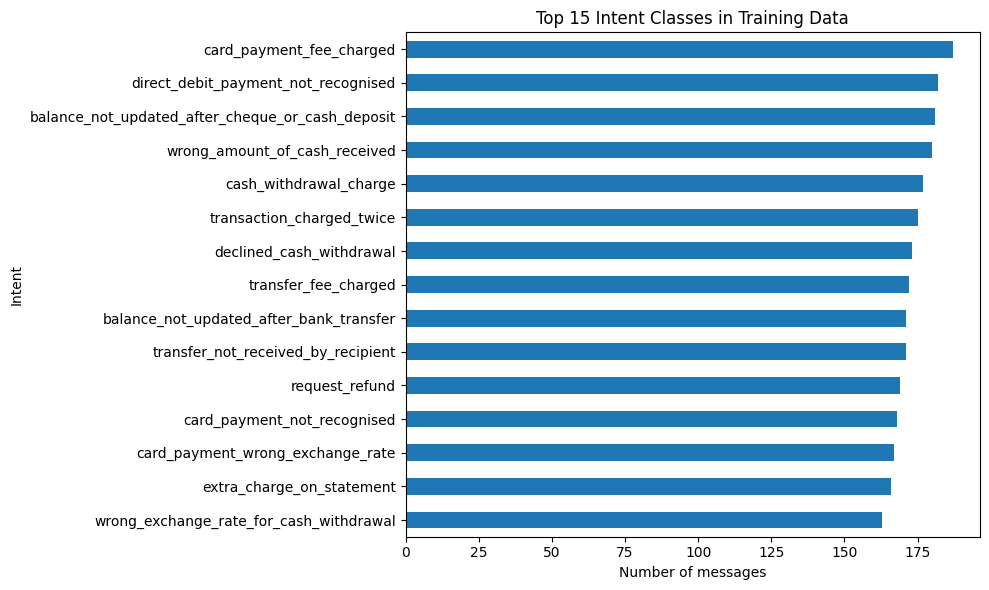

In [37]:
import matplotlib.pyplot as plt

top_classes = class_counts.head(15)

plt.figure(figsize=(10, 6))
top_classes.sort_values().plot(kind="barh")

plt.xlabel("Number of messages")
plt.ylabel("Intent")
plt.title("Top 15 Intent Classes in Training Data")
plt.tight_layout()
plt.show()

In [40]:
train_df["char_length"] = train_df["text"].str.len()

train_df["word_count"] = (
    train_df["text"]
    .str.split()
    .str.len()
)

In [46]:
train_df["char_length"].describe()

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: char_length, dtype: float64

In [47]:
train_df["word_count"].describe()

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64

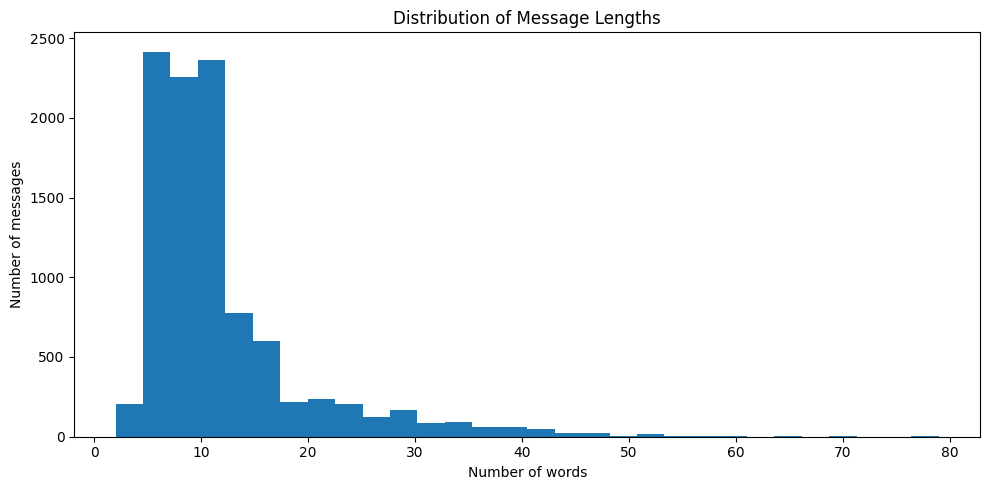

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["word_count"], bins=30)

plt.xlabel("Number of words")
plt.ylabel("Number of messages")
plt.title("Distribution of Message Lengths")

plt.tight_layout()
plt.show()

In [48]:
train_df[
    ["text", "intent"]
].sample(15, random_state=42)

,text,intent
6883,Is it possible for me to change my PIN number?,change_pin
5836,I'm not sure why my card didn't work,declined_card_payment
8601,I don't think my top up worked,top_up_failed
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged
8697,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
5573,Why am I getting declines when trying to make ...,declined_transfer
576,What is the $1 transaction on my account?,extra_charge_on_statement
6832,It looks like my card payment was sent back.,reverted_card_payment?
7111,Why am I unable to transfer money when I was a...,beneficiary_not_allowed
439,What if there is an error on the exchange rate?,card_payment_wrong_exchange_rate
